In [85]:
# Обоснование наихудшего сценария в секции — загрузка исходных данных
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

if '../src' not in sys.path:
    sys.path.append('../src')
from database import load_corrosion_data as load_data

TARGET = 'corr_rate_section_mm_per_year'

DF_full = load_data()
assert TARGET in DF_full.columns, f'В данных отсутствует {TARGET}'

print(f"Исходные данные: {len(DF_full):,} строк, {len(DF_full.columns)} колонок")
print('Колонки:', sorted(DF_full.columns.tolist()))

OperationalError: (psycopg2.OperationalError) connection to server at "100.98.56.203", port 5432 failed: Connection timed out (0x0000274C/10060)
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [62]:
def plot_corr_by_components(equipment_id=None, component_type_code=1, min_measurements=2):
    """Boxplot: распределение скорости коррозии по компонентам equipment (участок, ≥min_measurements замеров, сортировка по Ø внешнему)."""
    df = DF_full.copy()
    if equipment_id is not None:
        df = df[df['equipment_id'] == equipment_id]
    df = df[df['component_type_code'] == component_type_code]
    cols = ['component_id', 'component', 'equipment', TARGET, 'inner_diameter', 'outer_diameter', 'initial_thickness', 'material_code']
    df = df[[c for c in cols if c in df.columns]].dropna(subset=[TARGET])
    counts = df.groupby('component_id').size()
    df = df[df['component_id'].isin(counts[counts >= min_measurements].index)]
    if df.empty:
        print(f"Нет данных (equipment_id={equipment_id})")
        return
    comp_info = df.groupby('component_id').agg({k: 'first' for k in cols if k in df.columns}).round(1)
    comp_info = comp_info.sort_values('outer_diameter', ascending=False, na_position='last')
    comp_ids = comp_info.index.tolist()
    labels = []
    for cid in comp_ids:
        r = comp_info.loc[cid]
        name = str(r.get('component', ''))[:25] if pd.notna(r.get('component')) and str(r.get('component', '')).strip() else f'ID {cid}'
        parts = []
        if pd.notna(r.get('inner_diameter')): parts.append(f"Ø{r['inner_diameter']:.0f}")
        if pd.notna(r.get('outer_diameter')) and (pd.isna(r.get('inner_diameter')) or r['inner_diameter'] != r['outer_diameter']): parts.append(f"Ø{r['outer_diameter']:.0f}")
        if pd.notna(r.get('initial_thickness')): parts.append(f"t={r['initial_thickness']:.1f}")
        if pd.notna(r.get('material_code')): parts.append(f"mat={r['material_code']}")
        labels.append(f"{name}\n{cid}" + (f" ({', '.join(parts)})" if parts else ""))
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df, x='component_id', y=TARGET, order=comp_ids, color='steelblue', ax=ax)
    ax.set_xticks(range(len(comp_ids)))
    ax.set_xticklabels(labels)
    ax.set_xlabel('Компонент — ID (Ø, t, mat)')
    ax.set_ylabel('Скорость коррозии, мм/год')
    title = 'Распределение скорости коррозии по компонентам equipment'
    if equipment_id is not None:
        title += f' (equipment_id={equipment_id})'
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(f"Компонентов: {df['component_id'].nunique()}, наблюдений: {len(df):,}")


def plot_corr_median_by_components(equipment_id=None, component_type_code=1, min_measurements=2):
    """График медианной скорости коррозии по компонентам (участок, ≥min_measurements замеров, сортировка по Ø внешнему)."""
    df = DF_full.copy()
    if equipment_id is not None:
        df = df[df['equipment_id'] == equipment_id]
    df = df[df['component_type_code'] == component_type_code]
    cols = ['component_id', 'component', 'equipment', TARGET, 'inner_diameter', 'outer_diameter', 'initial_thickness', 'material_code']
    df = df[[c for c in cols if c in df.columns]].dropna(subset=[TARGET])
    counts = df.groupby('component_id').size()
    df = df[df['component_id'].isin(counts[counts >= min_measurements].index)]
    if df.empty:
        print(f"Нет данных (equipment_id={equipment_id})")
        return
    comp_info = df.groupby('component_id').agg({k: 'first' for k in cols if k in df.columns}).round(1)
    comp_info = comp_info.sort_values('outer_diameter', ascending=False, na_position='last')
    comp_ids = comp_info.index.tolist()
    medians = df.groupby('component_id')[TARGET].median().reindex(comp_ids).values
    labels = []
    for cid in comp_ids:
        r = comp_info.loc[cid]
        name = str(r.get('component', ''))[:25] if pd.notna(r.get('component')) and str(r.get('component', '')).strip() else f'ID {cid}'
        parts = []
        if pd.notna(r.get('inner_diameter')): parts.append(f"Ø{r['inner_diameter']:.0f}")
        if pd.notna(r.get('outer_diameter')) and (pd.isna(r.get('inner_diameter')) or r['inner_diameter'] != r['outer_diameter']): parts.append(f"Ø{r['outer_diameter']:.0f}")
        if pd.notna(r.get('initial_thickness')): parts.append(f"t={r['initial_thickness']:.1f}")
        if pd.notna(r.get('material_code')): parts.append(f"mat={r['material_code']}")
        labels.append(f"{name}\n{cid}" + (f" ({', '.join(parts)})" if parts else ""))
    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(comp_ids))
    ax.scatter(x, medians, s=80, color='steelblue', edgecolor='navy', alpha=0.9, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Компонент — ID (Ø, t, mat)')
    ax.set_ylabel('Медианная скорость коррозии, мм/год')
    title = 'Медианная скорость коррозии по компонентам'
    
    if equipment_id is not None:
        title += f' (equipment_id={equipment_id})'
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(f"Компонентов: {df['component_id'].nunique()}, наблюдений: {len(df):,}")

def plot_corr_histogram(equipment_id=None, installation_id=None, component_type_code=1, bins=30):
    """Гистограмма скорости коррозии (по отфильтрованным данным). Показывает скошенность и «длинный хвост»."""
    df = DF_full.copy()
    if equipment_id is not None:
        df = df[df['equipment_id'] == equipment_id]
    if installation_id is not None:
        df = df[df['installation_id'] == installation_id]
    df = df[df['component_type_code'] == component_type_code].dropna(subset=[TARGET])
    if df.empty:
        print("Нет данных")
        return
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df[TARGET], bins=bins, color='steelblue', edgecolor='navy', alpha=0.8)
    ax.axvline(df[TARGET].median(), color='red', linestyle='--', linewidth=2, label=f'Медиана = {df[TARGET].median():.4f}')
    ax.set_xlabel('Скорость коррозии, мм/год')
    ax.set_ylabel('Частота')
    title = 'Распределение скорости коррозии'
    if installation_id is not None:
        title += f' (installation_id={installation_id})'
    elif equipment_id is not None:
        title += f' (equipment_id={equipment_id})'
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Наблюдений: {len(df):,}, медиана: {df[TARGET].median():.4f}")





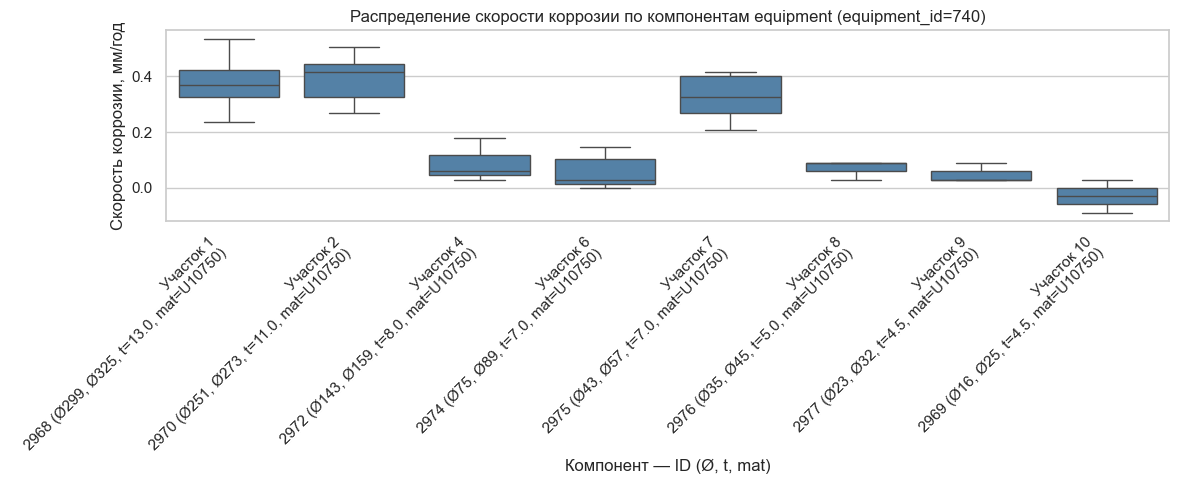

Компонентов: 8, наблюдений: 42


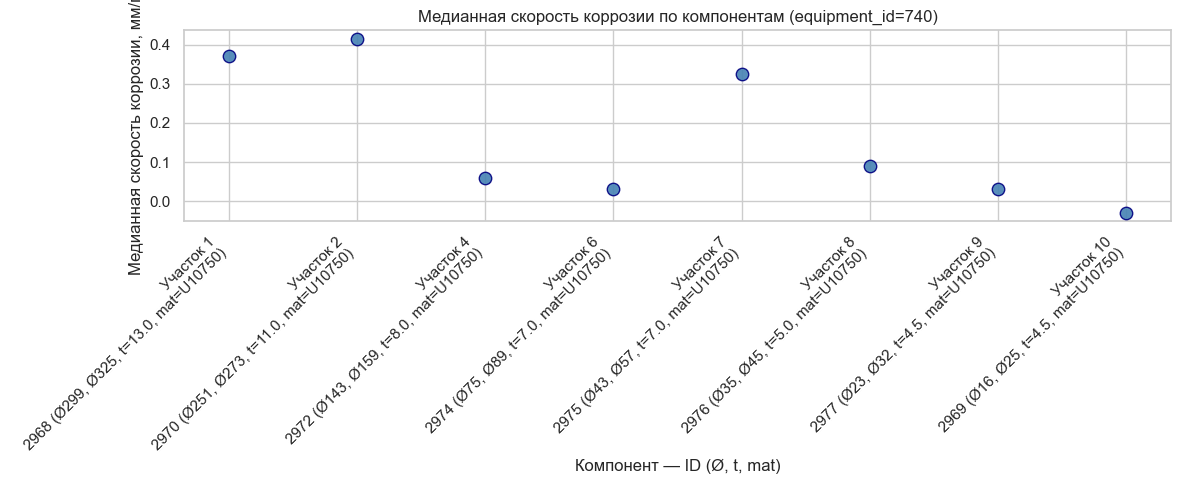

Компонентов: 8, наблюдений: 42


In [ ]:
plot_corr_by_components(equipment_id=740)
plot_corr_median_by_components(equipment_id=740)



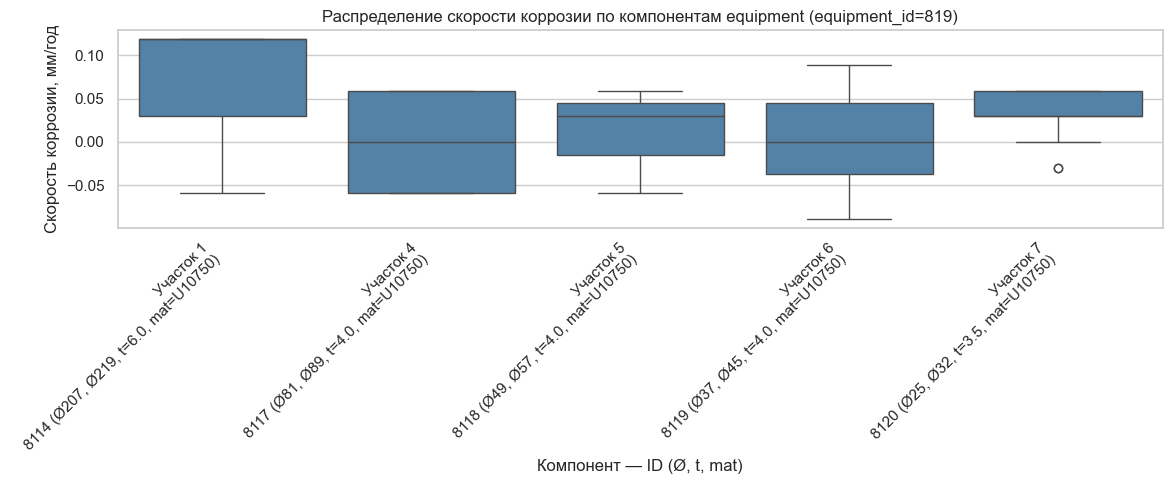

Компонентов: 5, наблюдений: 35


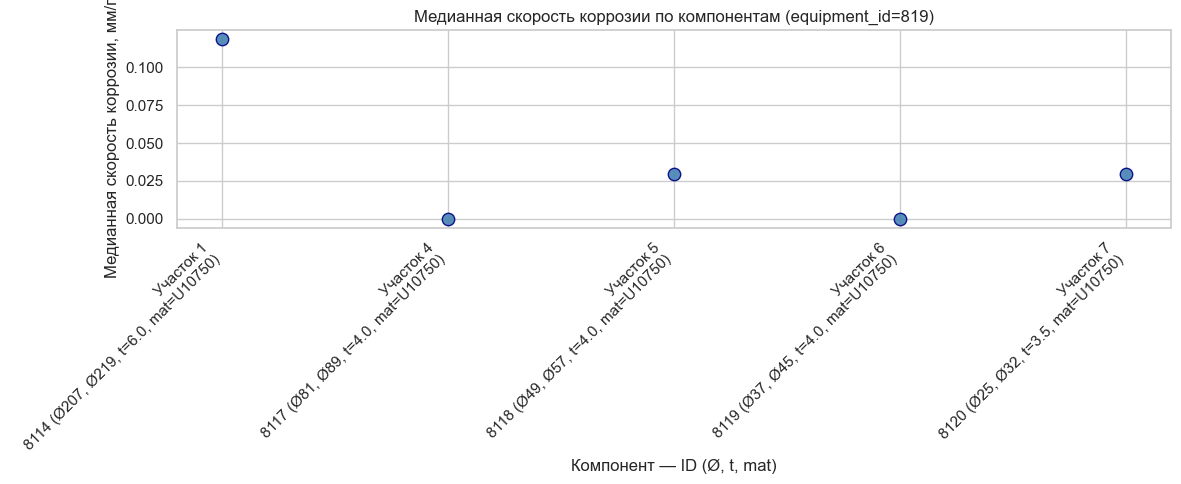

Компонентов: 5, наблюдений: 35


In [ ]:
plot_corr_by_components(equipment_id=819)
plot_corr_median_by_components(equipment_id=819)
